In [170]:
# Project root — edit for your environment.
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"


In [171]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np

In [172]:
# go_df=pd.read_csv(f"{PROJ_ROOT}/figure/circos-plot/segdup-feature/segdup_genes_hotspots.tsv", sep="\t", index_col=0)
# go_df=pd.read_csv(f"{PROJ_ROOT}/figure/segdup-investigation/segdup_genes_hotspots_bpLevel_elemDecomposition.tsv", sep="\t", index_col=0)
# go_df=pd.read_csv(f"{PROJ_ROOT}/figure/segdup-investigation/segdup_genes_hotspots_bpLevel_seqRemoved_top95percentile.tsv", sep="\t", index_col=0)
go_df=pd.read_csv("segdup_genes_hotspots_80percLength.tsv", sep="\t", index_col=0)

# background_df=pd.read_csv(f"{PROJ_ROOT}/figure/segdup-investigation/segdup_genes_hotspots_bpLevel.tsv", sep="\t", index_col=0)
background_df = pd.read_csv("hifiasm_gene_segDup_overlapInfo_081726.tsv", sep="\t")
# Use only segdup-overlapping genes as background (stringent test: hotspot vs other segdup genes)
background_df = background_df[background_df["overlaps_dup"].astype(str).str.strip().str.upper().isin(["TRUE", "1"])]

In [173]:

print(background_df.shape)

(10397, 14)


In [174]:
print(go_df.shape)

(1271, 14)


In [175]:
search_terms = ["Gbp1", "Gbp5", "Gbp6", "Ifng", "Casp1", "Ccl3", "Lgals9", "Syncrip"]
pattern = "|".join(search_terms)

# This version handles missing values and is case-insensitive
filtered_go_df = go_df[
    go_df["gene"].str.contains(pattern, case=False, na=False)
]

filtered_go_df

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
9805,433463,chr7,Liftoff,gene,20426533,20428097,.,+,.,ID=gene-Ccl3;Dbxref=GeneID:101587128;Name=Ccl3...,CCL3,20426532,20428097,True
9807,433483,chr7,Liftoff,gene,20488118,20489595,.,+,.,ID=gene-Ccl3l1;Dbxref=GeneID:101586327;Name=Cc...,CCL3L1,20488117,20489595,True
9808,433492,chr7,Liftoff,gene,20530102,20531792,.,-,.,ID=gene-Ccl3l3;Dbxref=GeneID:101585538;Name=Cc...,CCL3L3,20530101,20531792,True
9810,433512,chr7,Liftoff,gene,20573877,20575422,.,-,.,ID=gene-Ccl3-l1;Dbxref=GeneID:101584743;Name=C...,CCL3-L1,20573876,20575422,True
9887,436241,chr7,Liftoff,gene,27127112,27130068,.,+,.,ID=gene-Lgals9b;Dbxref=GeneID:101587831;Name=L...,LGALS9B,27127111,27130068,True
9889,436258,chr7,Liftoff,gene,27175701,27186843,.,-,.,ID=gene-Lgals9-l1;Dbxref=GeneID:111817848;Name...,LGALS9-L1,27175700,27186843,True
9890,436281,chr7,Liftoff,gene,27209602,27230912,.,-,.,ID=gene-Lgals9b-l1;Dbxref=GeneID:111817837;Nam...,LGALS9B-L1,27209601,27230912,True
9892,436310,chr7,Liftoff,gene,27317389,27323411,.,-,.,ID=gene-Lgals9-l2;Dbxref=GeneID:111812005;Name...,LGALS9-L2,27317388,27323411,True
16432,749753,chr15,Liftoff,gene,14303053,14342384,.,-,.,ID=gene-Syncrip;Dbxref=GeneID:101560287;Name=S...,SYNCRIP,14303052,14342384,True
17331,791272,chr16,Liftoff,gene,29422928,29426617,.,+,.,ID=gene-Ifng;Dbxref=GeneID:101561507;Name=Ifng...,IFNG,29422927,29426617,True


In [176]:
gene_list = go_df["gene"]
cleaned = gene_list.str.replace(r"-(?:DL|RL|L)\d+$", "", regex=True)
unique_genes=cleaned.unique()
print(len(unique_genes))
unique_genes

background_list = background_df["gene"]
cleaned = background_list.str.replace(r"-(?:DL|RL|L)\d+$", "", regex=True)
background_genes=cleaned.unique()
print(len(background_genes))

1086
8834


In [177]:
import requests

# Download the latest human GO Biological Process GMT
url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2025"
response = requests.get(url)
with open("human_GO_bp_2025.gmt", "w") as f:
    f.write(response.text)

In [178]:
# Filter out genes containing "LOC"
filtered_genes = unique_genes[~pd.Series(unique_genes).str.contains("LOC", na=False)]
filtered_genes = np.unique(filtered_genes)
print(len(filtered_genes))
filtered_genes


# Filter out genes containing "LOC"
background_genes = background_genes[~pd.Series(background_genes).str.contains("LOC", na=False)]
background_genes = np.unique(background_genes)
print(len(background_genes))

## Put this in metascape
filtered_genes

469
6814


array(['AADAC', 'ABCG2', 'ACAA2', 'ACAD10', 'ACO1', 'ADAM20', 'ADAM3',
       'ADAMTSL1', 'ADGRD1', 'ADH7', 'AIF1L', 'AKR1B10', 'AKR1B8',
       'ALDH1A1', 'ALOX12E', 'AMD1', 'AMY1', 'AMY2', 'APOL2', 'APOL3',
       'AQR', 'ARF4', 'ARHGAP30', 'ARMC3', 'ARPC5', 'ASNS', 'ATG12',
       'BBS9', 'BDP1', 'BIRC2', 'BMP8B', 'BMPER', 'BNIP3', 'BOLL', 'BRK1',
       'C3ORF20', 'CASP1', 'CASP2', 'CCDC14', 'CCDC174', 'CCL3', 'CCL3L1',
       'CCL3L3', 'CCL4', 'CCNB1', 'CCT3', 'CCT4', 'CCT7', 'CD1B2', 'CD33',
       'CEACAM1', 'CEACAM21', 'CEL', 'CENPI', 'CEP78', 'CES1', 'CES2E',
       'CFAP206', 'CFAP54', 'CH1', 'CHCHD2', 'CHD2', 'CHFR', 'CIAO2B',
       'CLCA4', 'CMC1', 'CNOT10', 'COIL', 'COPG2', 'COPS4', 'COX15',
       'CPD', 'CPM', 'CRLF3', 'CSDE1', 'CSE1L', 'CSF2RB', 'CST3',
       'CTAGE9', 'CTRB1', 'CUL2', 'CUNH14ORF39', 'CUNH3ORF20',
       'CUNH4ORF17', 'CXCL17', 'CYP11B1', 'CYP2A6', 'CYP2B4', 'CYP2C25',
       'CYP2D16', 'CYP2D4', 'CYP2J2', 'CYP3A4', 'CYTH3', 'DARS', 'DDX11',
       'D

In [179]:
list(filtered_genes)

['AADAC',
 'ABCG2',
 'ACAA2',
 'ACAD10',
 'ACO1',
 'ADAM20',
 'ADAM3',
 'ADAMTSL1',
 'ADGRD1',
 'ADH7',
 'AIF1L',
 'AKR1B10',
 'AKR1B8',
 'ALDH1A1',
 'ALOX12E',
 'AMD1',
 'AMY1',
 'AMY2',
 'APOL2',
 'APOL3',
 'AQR',
 'ARF4',
 'ARHGAP30',
 'ARMC3',
 'ARPC5',
 'ASNS',
 'ATG12',
 'BBS9',
 'BDP1',
 'BIRC2',
 'BMP8B',
 'BMPER',
 'BNIP3',
 'BOLL',
 'BRK1',
 'C3ORF20',
 'CASP1',
 'CASP2',
 'CCDC14',
 'CCDC174',
 'CCL3',
 'CCL3L1',
 'CCL3L3',
 'CCL4',
 'CCNB1',
 'CCT3',
 'CCT4',
 'CCT7',
 'CD1B2',
 'CD33',
 'CEACAM1',
 'CEACAM21',
 'CEL',
 'CENPI',
 'CEP78',
 'CES1',
 'CES2E',
 'CFAP206',
 'CFAP54',
 'CH1',
 'CHCHD2',
 'CHD2',
 'CHFR',
 'CIAO2B',
 'CLCA4',
 'CMC1',
 'CNOT10',
 'COIL',
 'COPG2',
 'COPS4',
 'COX15',
 'CPD',
 'CPM',
 'CRLF3',
 'CSDE1',
 'CSE1L',
 'CSF2RB',
 'CST3',
 'CTAGE9',
 'CTRB1',
 'CUL2',
 'CUNH14ORF39',
 'CUNH3ORF20',
 'CUNH4ORF17',
 'CXCL17',
 'CYP11B1',
 'CYP2A6',
 'CYP2B4',
 'CYP2C25',
 'CYP2D16',
 'CYP2D4',
 'CYP2J2',
 'CYP3A4',
 'CYTH3',
 'DARS',
 'DDX11',
 'DDX50',
 

<Figure size 1000x800 with 0 Axes>

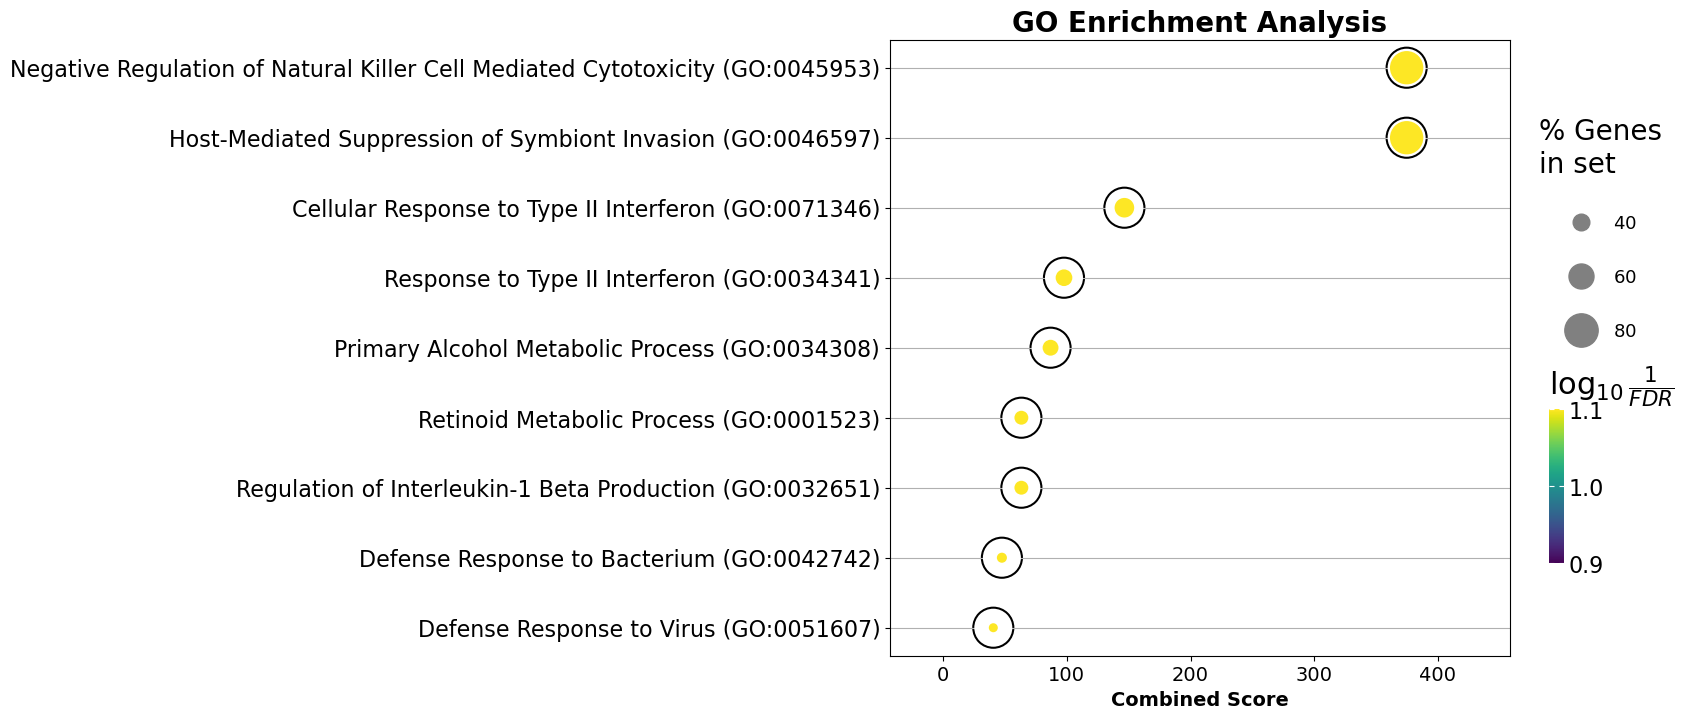

In [180]:
# Perform GO enrichment analysis
go_results  = gp.enrichr(
    gene_list=list(filtered_genes),  # Your converted gene list
    gene_sets="human_GO_bp_2025.gmt",     # Custom GMT file
    background=list(background_genes),  # Now this will be used!
    outdir=None
)

go_df = go_results.results
go_df.to_csv('go_enrichment_results_segdup_hotspot_seqRemoved_80percLength.csv', index=False)

# Plot top terms
plt.figure(figsize=(10, 8))
gp.dotplot(go_results.results, 
           title='GO Enrichment Analysis',
           cutoff=0.05,  # p-value cutoff
           top_term=10,  # show top 10 terms
           fontsize = 12,
           figsize=(10, 8),
           show_ring=True,
           cmap='viridis')
plt.savefig('go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

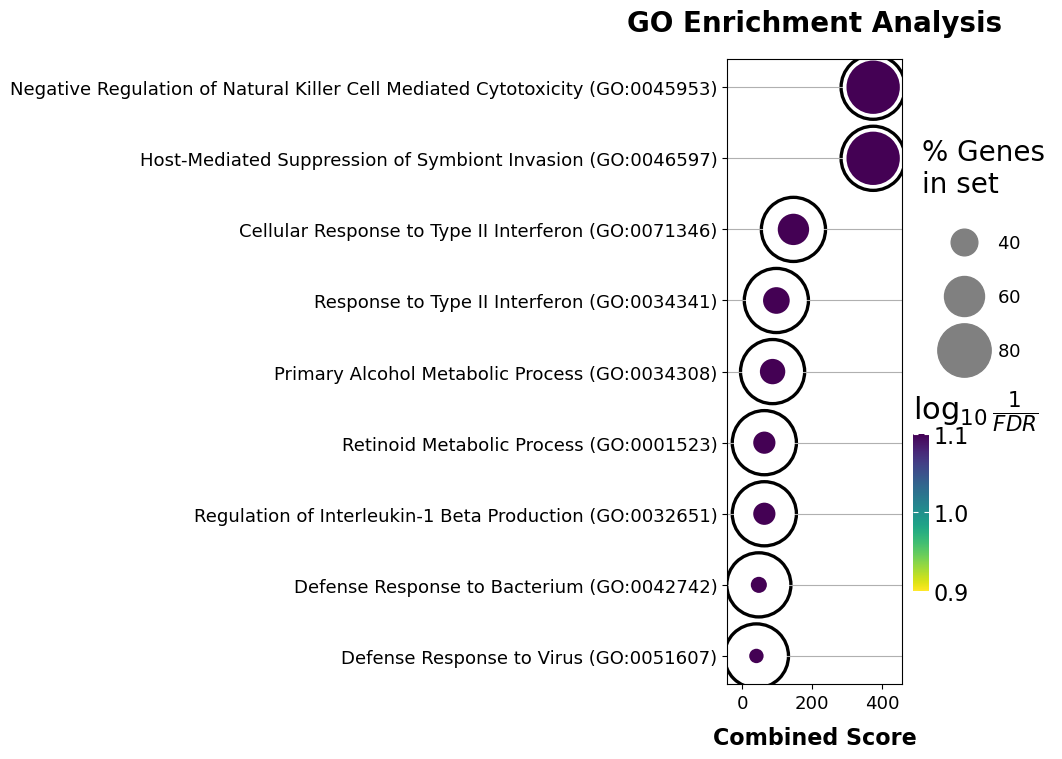

In [181]:
import matplotlib.pyplot as plt
import gseapy as gp

# Perform GO enrichment analysis
go_results = gp.enrichr(
    gene_list=list(filtered_genes),
    gene_sets="human_GO_bp_2025.gmt",
    background=list(background_genes),
    outdir=None
)

# Save results
go_df = go_results.results
# go_df.to_csv('go_enrichment_results_segdup_hotspot.csv', index=False)

# --- Publication-quality plot ---
plt.figure(figsize=(12, 6))

ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 8),
    cmap='viridis_r',          # inverted colormap for contrast
    show_ring=True,
    marker='o',
    size=8,                    # increase circle size
    linewidth=1.2,             # thicker outline around circles
    edgecolor='black',         # black border for visibility
    alpha=0.9,                 # slightly transparent for overlapping
    fontsize=14,               # increase text size
)

# --- Further aesthetic adjustments ---
plt.title('GO Enrichment Analysis', fontsize=20, weight='bold', pad=20)
plt.xlabel('Combined Score', fontsize=16, labelpad=10)
plt.ylabel('', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# plt.grid(False)

# Tight layout and high-res save
plt.tight_layout()
# plt.savefig('go_enrichment_plot_segdup_hotspot_pubready.png', dpi=600, bbox_inches='tight')
plt.show()

In [182]:
ax.get_yticklabels()

[Text(0, 0, 'Defense Response to Virus (GO:0051607)'),
 Text(0, 1, 'Defense Response to Bacterium (GO:0042742)'),
 Text(0, 2, 'Regulation of Interleukin-1 Beta Production (GO:0032651)'),
 Text(0, 3, 'Retinoid Metabolic Process (GO:0001523)'),
 Text(0, 4, 'Primary Alcohol Metabolic Process (GO:0034308)'),
 Text(0, 5, 'Response to Type II Interferon (GO:0034341)'),
 Text(0, 6, 'Cellular Response to Type II Interferon (GO:0071346)'),
 Text(0, 7, 'Host-Mediated Suppression of Symbiont Invasion (GO:0046597)'),
 Text(0, 8, 'Negative Regulation of Natural Killer Cell Mediated Cytotoxicity (GO:0045953)')]

In [183]:
import textwrap

# Wrap long GO term labels to multiple lines
new_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    wrapped = "\n".join(textwrap.wrap(text, width=30))  # wrap every 30 characters
    new_labels.append(wrapped)
ax.set_yticklabels(new_labels)

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_829896/2655881135.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels)


[Text(0, 0, 'Defense Response to Virus\n(GO:0051607)'),
 Text(0, 1, 'Defense Response to Bacterium\n(GO:0042742)'),
 Text(0, 2, 'Regulation of Interleukin-1\nBeta Production (GO:0032651)'),
 Text(0, 3, 'Retinoid Metabolic Process\n(GO:0001523)'),
 Text(0, 4, 'Primary Alcohol Metabolic\nProcess (GO:0034308)'),
 Text(0, 5, 'Response to Type II Interferon\n(GO:0034341)'),
 Text(0, 6, 'Cellular Response to Type II\nInterferon (GO:0071346)'),
 Text(0, 7, 'Host-Mediated Suppression of\nSymbiont Invasion (GO:0046597)'),
 Text(0, 8, 'Negative Regulation of Natural\nKiller Cell Mediated\nCytotoxicity (GO:0045953)')]

In [184]:
go_results.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/17,0.107343,0.657935,3.276084,7.311313,CCT3;CCT7;CCT4
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/3,0.013536,0.351166,22.618538,97.314454,IFNG;LGALS9
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/4,0.001230,0.120539,31.733834,212.640366,RHOT1;VDAC2;BNIP3
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/2,0.132930,0.657935,13.542156,27.327183,SIVA1
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/3,0.192627,0.658898,8.124013,13.380256,PLCG2
...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/3,0.192627,0.658898,8.124013,13.380256,SLFN13
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/11,0.172459,0.658898,3.566845,6.269077,SLFN13;LAGE3
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/30,0.882826,0.932295,0.685545,0.085437,QTRT2
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/3,0.192627,0.658898,8.124013,13.380256,LAGE3


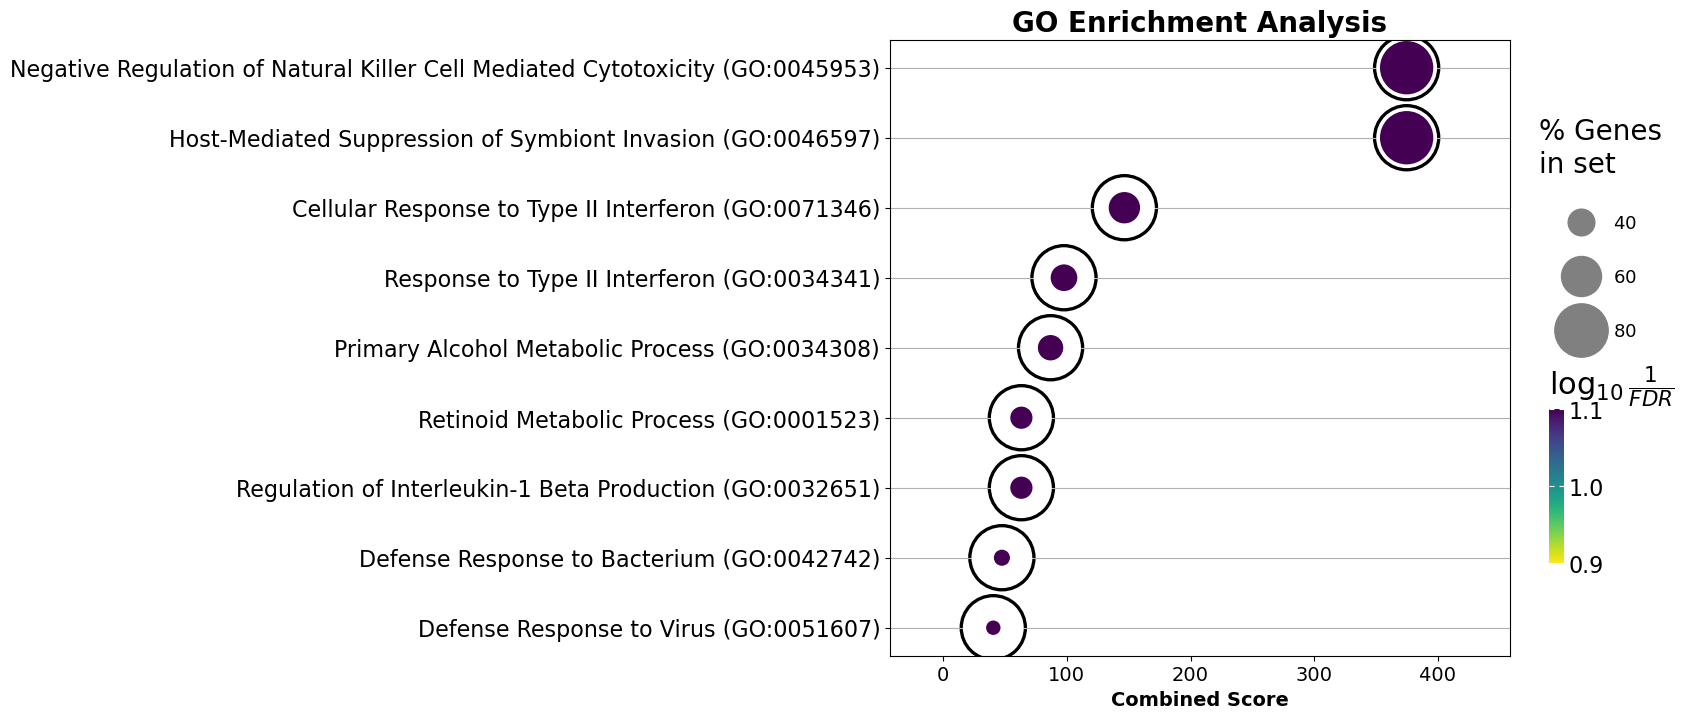

In [185]:
ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 8),
    cmap='viridis_r',          # inverted colormap for contrast
    show_ring=True,
    marker='o',
    size=8,                    # increase circle size
    linewidth=1.2,             # thicker outline around circles
    edgecolor='black',         # black border for visibility
    alpha=0.9,                 # slightly transparent for overlapping
    fontsize=14,               # increase text size
)

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_829896/1021594630.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels, fontsize=16, fontweight='bold')


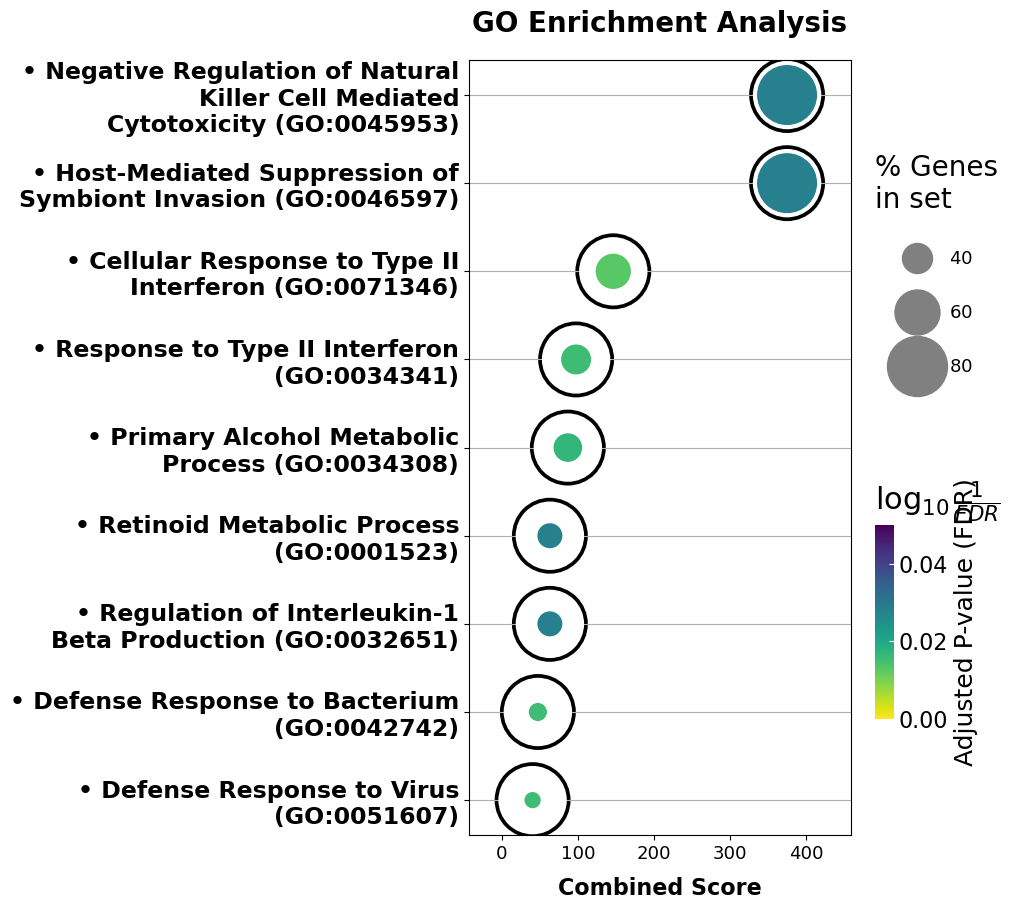

In [187]:

# Set global font sizes before plotting
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 13,
})

ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 9.5),
    cmap='viridis_r',
    show_ring=True,
    marker='o',
    size=9,
    linewidth=1.2,
    edgecolor='black',
    alpha=0.9,
    fontsize=14,
)

# Re-color the dots from -log10(FDR) to RAW FDR (colorbar = Adjusted P-value)
_sc = None
for _coll in ax.collections:
    _a = _coll.get_array()
    if _a is not None and len(_a) > 1:
        _sc = _coll
if _sc is not None:
    _sc.set_array(10.0 ** (-_sc.get_array()))
    _sc.set_clim(0.0, 0.05)
    if getattr(_sc, "colorbar", None) is not None:
        _sc.colorbar.set_label("Adjusted P-value (FDR)")
        _sc.colorbar.update_normal(_sc)


# --- Add bullet points + wrap long GO term labels ---
new_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    # Wrap every 30 characters and add a bullet point at the start
    wrapped = "\n".join(textwrap.wrap(text, width=30))
    wrapped = f"• {wrapped}"
    new_labels.append(wrapped)
ax.set_yticklabels(new_labels, fontsize=16, fontweight='bold')

# --- Further aesthetic adjustments ---
plt.title('GO Enrichment Analysis', fontsize=20, weight='bold', pad=20)
plt.xlabel('Combined Score', fontsize=16, labelpad=10)
plt.xticks(fontsize=13)
plt.yticks(fontsize=17, fontweight='bold')
# cbar = ax.collections[0].colorbar
# cbar.ax.tick_params(labelsize=14)  # <- controls the numeric tick font size

plt.tight_layout()
plt.savefig('go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength_pubready.png', dpi=600, bbox_inches='tight')
plt.savefig('go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength_pubready.svg', dpi=600, bbox_inches='tight')
plt.show()

In [154]:
go_df["numGene"] = go_df["Overlap"].astype(str).str.split("/").str[0]


In [155]:
go_df[go_df["Term"].str.contains("Defense")]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene
272,human_GO_bp_2025.gmt,Defense Response to Bacterium (GO:0042742),14/58,0.000027,0.015571,4.507789,47.447172,GSDMC;CASP1;LCN2;SFTPD;RNASE1;RNASE6;MPEG1;GBP...,14
273,human_GO_bp_2025.gmt,Defense Response to Fungus (GO:0050832),2/4,0.025842,0.444293,13.568984,49.605117,S100A8;PLCG2,2
274,human_GO_bp_2025.gmt,Defense Response to Gram-negative Bacterium (G...,3/16,0.092937,0.657935,3.519312,8.361317,RNASE6;LYZ;MPEG1,3
275,human_GO_bp_2025.gmt,Defense Response to Gram-positive Bacterium (G...,6/23,0.003792,0.247729,5.071382,28.272568,RNASE1;RNASE6;MPEG1;GBP6;LYZ;RNASE9,6
276,human_GO_bp_2025.gmt,Defense Response to Protozoan (GO:0042832),2/4,0.025842,0.444293,13.568984,49.605117,GBP6;GBP1,2
277,human_GO_bp_2025.gmt,Defense Response to Symbiont (GO:0140546),1/2,0.132930,0.657935,13.542156,27.327183,LYZ,1
278,human_GO_bp_2025.gmt,Defense Response to Virus (GO:0051607),16/74,0.000032,0.015571,3.910468,40.499856,IFITM3;CASP1;MX2;GBP5;IFIT1B;RNASE1;RNASE6;EXO...,16
653,human_GO_bp_2025.gmt,Negative Regulation of Defense Response (GO:00...,5/41,0.148398,0.658898,2.046817,3.905041,ATG12;DTX4;PTPN2;CXCL17;FPR2,5
1006,human_GO_bp_2025.gmt,Positive Regulation of Defense Response (GO:00...,7/34,0.007386,0.351166,3.725897,18.287269,LILRA5;CASP1;CCL3;GBP5;IFNG;S100A8;FPR2,7
1440,human_GO_bp_2025.gmt,Regulation of Defense Response (GO:0031347),4/35,0.218198,0.672600,1.937855,2.950094,CASP1;XIAP;SAMHD1;BIRC2,4


In [156]:
go_df.sort_values("Combined Score").tail(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene
207,human_GO_bp_2025.gmt,Cellular Response to Type II Interferon (GO:00...,8/17,0.000007,0.012999,12.284940,146.480776,CASP1;CCL3;GBP5;IFNG;LGALS9;GBP6;SYNCRIP;GBP1,8
542,human_GO_bp_2025.gmt,Mitochondrial Outer Membrane Permeabilization ...,3/4,0.001230,0.120539,31.733834,212.640366,RHOT1;VDAC2;BNIP3,3
706,human_GO_bp_2025.gmt,Negative Regulation of Leukocyte Mediated Cyto...,3/4,0.001230,0.120539,31.733834,212.640366,CEACAM1;GRB2;LGALS9,3
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/4,0.001230,0.120539,31.733834,212.640366,RHOT1;VDAC2;BNIP3,3
1055,human_GO_bp_2025.gmt,Positive Regulation of Interleukin-23 Producti...,2/2,0.004728,0.280815,67.866310,363.373284,IFNG;PLCG2,2
208,human_GO_bp_2025.gmt,Cellular Response to Type III Interferon (GO:0...,2/2,0.004728,0.280815,67.866310,363.373284,IFNL4;IFNL3,2
1892,human_GO_bp_2025.gmt,Type III Interferon-Mediated Signaling Pathway...,2/2,0.004728,0.280815,67.866310,363.373284,IFNL4;IFNL3,2
424,human_GO_bp_2025.gmt,Host-Mediated Suppression of Symbiont Invasion...,4/5,0.000105,0.028402,40.888292,374.667927,IFITM3;TRIM5;SNX3;LY6E,4
730,human_GO_bp_2025.gmt,Negative Regulation of Natural Killer Cell Med...,4/5,0.000105,0.028402,40.888292,374.667927,CEACAM1;GRB2;SERPINB9;LGALS9,4
1504,human_GO_bp_2025.gmt,Regulation of Interleukin-23 Production (GO:00...,3/3,0.000324,0.053721,95.216506,765.003986,RNASE1;IFNG;PLCG2,3


In [157]:
go_df.sort_values("numGene").tail(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene
967,human_GO_bp_2025.gmt,Positive Regulation of Cell Migration (GO:0030...,9/116,0.404992,0.719982,1.197197,1.082132,CCL3;CCL4;RNASE1;IFNG;TCAF2;CCL3L1;PLCG2;SERPI...,9
1811,human_GO_bp_2025.gmt,Small GTPase-mediated Signal Transduction (GO:...,9/81,0.103197,0.657935,1.785114,4.054194,BRK1;RALGDS;RNASE1;GRB2;USP8;USP50;SOS2;ARHGAP...,9
1687,human_GO_bp_2025.gmt,Regulation of Translation (GO:0006417),9/124,0.484888,0.737353,1.112846,0.805520,EIF4ENIF1;DHFR;SYNCRIP;EIF5B;CSDE1;RPL26;CNOT1...,9
1278,human_GO_bp_2025.gmt,Protein Maturation (GO:0051604),9/66,0.035738,0.534704,2.256177,7.516553,CASP1;NAA16;SDE2;GZMH;CPM;CASP2;KLK4;CIAO2B;GZMB,9
757,human_GO_bp_2025.gmt,Negative Regulation of Protein Metabolic Proce...,9/69,0.045715,0.601356,2.143278,6.612702,SNX3;SERPINB3;EIF4ENIF1;DHFR;SYNCRIP;CNOT10;GZ...,9
1032,human_GO_bp_2025.gmt,Positive Regulation of Gene Expression (GO:001...,9/158,0.769206,0.871974,0.855065,0.224366,GJA1;CCL3;IFNG;LGALS9;CSDE1;RPS7;RPL26;RHOXF1;...,9
645,human_GO_bp_2025.gmt,Negative Regulation of Cytokine Production (GO...,9/56,0.013374,0.351166,2.735505,11.802145,CEACAM1;LILRA5;ATG12;SFTPD;RNASE1;IFNG;CD33;LG...,9
1046,human_GO_bp_2025.gmt,Positive Regulation of Inflammatory Response (...,9/34,0.000356,0.053721,5.113347,40.598480,LILRA5;CASP1;CCL3;GBP5;IFNG;NUPR1;S100A8;GBP1;...,9
248,human_GO_bp_2025.gmt,Cytoplasmic Translation (GO:0002181),9/69,0.045715,0.601356,2.143278,6.612702,RPL22;RPL10A;RPS27;RPL35;RPL9;RPS7;RPL23A;RPL2...,9
1946,human_GO_bp_2025.gmt,rRNA Metabolic Process (GO:0016072),9/58,0.016653,0.402970,2.624146,10.746252,SLFN12;RPS27;SLFN13;NIFK;SBDS;RPS7;RPL26;EXOSC...,9


In [158]:
go_df[go_df["Term"].str.contains("Defense")]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene
272,human_GO_bp_2025.gmt,Defense Response to Bacterium (GO:0042742),14/58,0.000027,0.015571,4.507789,47.447172,GSDMC;CASP1;LCN2;SFTPD;RNASE1;RNASE6;MPEG1;GBP...,14
273,human_GO_bp_2025.gmt,Defense Response to Fungus (GO:0050832),2/4,0.025842,0.444293,13.568984,49.605117,S100A8;PLCG2,2
274,human_GO_bp_2025.gmt,Defense Response to Gram-negative Bacterium (G...,3/16,0.092937,0.657935,3.519312,8.361317,RNASE6;LYZ;MPEG1,3
275,human_GO_bp_2025.gmt,Defense Response to Gram-positive Bacterium (G...,6/23,0.003792,0.247729,5.071382,28.272568,RNASE1;RNASE6;MPEG1;GBP6;LYZ;RNASE9,6
276,human_GO_bp_2025.gmt,Defense Response to Protozoan (GO:0042832),2/4,0.025842,0.444293,13.568984,49.605117,GBP6;GBP1,2
277,human_GO_bp_2025.gmt,Defense Response to Symbiont (GO:0140546),1/2,0.132930,0.657935,13.542156,27.327183,LYZ,1
278,human_GO_bp_2025.gmt,Defense Response to Virus (GO:0051607),16/74,0.000032,0.015571,3.910468,40.499856,IFITM3;CASP1;MX2;GBP5;IFIT1B;RNASE1;RNASE6;EXO...,16
653,human_GO_bp_2025.gmt,Negative Regulation of Defense Response (GO:00...,5/41,0.148398,0.658898,2.046817,3.905041,ATG12;DTX4;PTPN2;CXCL17;FPR2,5
1006,human_GO_bp_2025.gmt,Positive Regulation of Defense Response (GO:00...,7/34,0.007386,0.351166,3.725897,18.287269,LILRA5;CASP1;CCL3;GBP5;IFNG;S100A8;FPR2,7
1440,human_GO_bp_2025.gmt,Regulation of Defense Response (GO:0031347),4/35,0.218198,0.672600,1.937855,2.950094,CASP1;XIAP;SAMHD1;BIRC2,4


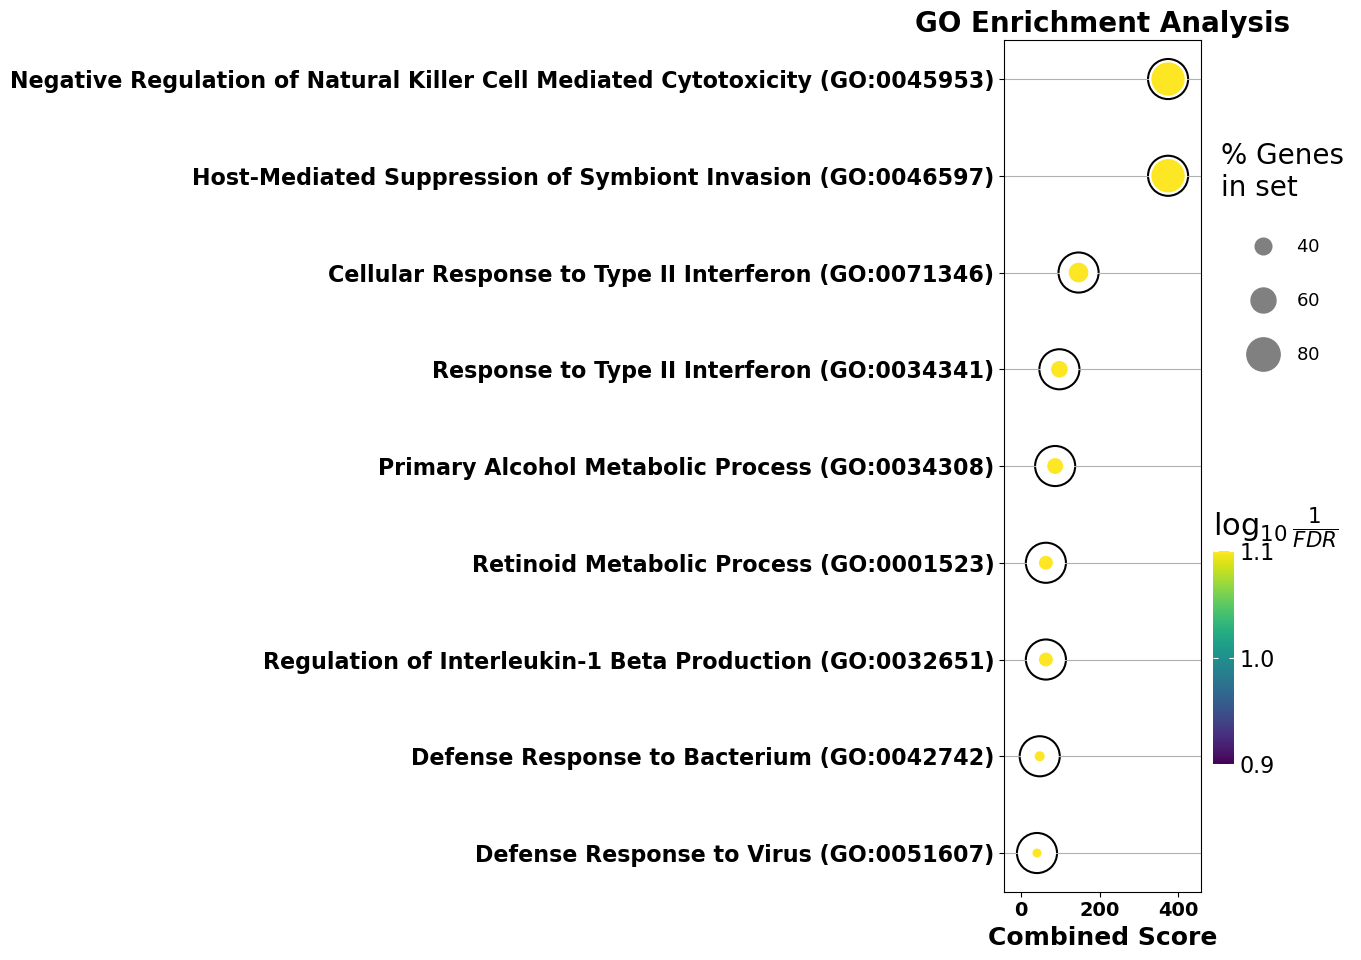

In [159]:
# plt.figure(figsize=(12, 8))
ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    fontsize=16,          # Increase base font size
    figsize=(13, 10),
    show_ring=True,
    cmap='viridis'
)

# Make title, labels, and ticks more visible
# plt.title('GO Enrichment Analysis', fontsize=22, fontweight='bold',loc='left') 
plt.xlabel('Combined Score', fontsize=18, fontweight='bold')
plt.ylabel('', fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Adjust colorbar label
# cbar = plt.gcf().axes[-1]  # last axis is colorbar
# cbar.tick_params(labelsize=12)
# cbar.set_ylabel(r'$\log_{10}\frac{1}{FDR}$', fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig('go_enrichment_plot_segdup_hotspot_bold.svg', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
go_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/17,0.107343,0.657935,3.276084,7.311313,CCT3;CCT7;CCT4,3
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/3,0.013536,0.351166,22.618538,97.314454,IFNG;LGALS9,2
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/4,0.001230,0.120539,31.733834,212.640366,RHOT1;VDAC2;BNIP3,3
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/2,0.132930,0.657935,13.542156,27.327183,SIVA1,1
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/3,0.192627,0.658898,8.124013,13.380256,PLCG2,1
...,...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/3,0.192627,0.658898,8.124013,13.380256,SLFN13,1
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/11,0.172459,0.658898,3.566845,6.269077,SLFN13;LAGE3,2
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/30,0.882826,0.932295,0.685545,0.085437,QTRT2,1
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/3,0.192627,0.658898,8.124013,13.380256,LAGE3,1


In [161]:
go_df["Term"]

0       'De Novo' Post-Translational Protein Folding (...
1       + Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...
2       + Reg of Mt Membrane Permeability Inv in Apopt...
3       + Reg of Mt Outer Membrane Permeabilization In...
4       + Reg of Myeloid Leukocyte Cytokine Production...
                              ...                        
1955                              tRNA Decay (GO:0016078)
1956                  tRNA Metabolic Process (GO:0006399)
1957                       tRNA Modification (GO:0006400)
1958    tRNA Threonylcarbamoyladenosine Metabolic Proc...
1959                          tRNA Transport (GO:0051031)
Name: Term, Length: 1960, dtype: object

In [162]:
go_df['GO_ID'] = go_df['Term'].str.extract(r'\((GO:\d+)\)')

In [163]:
go_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,numGene,GO_ID
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/17,0.107343,0.657935,3.276084,7.311313,CCT3;CCT7;CCT4,3,GO:0051084
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/3,0.013536,0.351166,22.618538,97.314454,IFNG;LGALS9,2,GO:0032831
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/4,0.001230,0.120539,31.733834,212.640366,RHOT1;VDAC2;BNIP3,3,GO:1902110
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/2,0.132930,0.657935,13.542156,27.327183,SIVA1,1,GO:1901030
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/3,0.192627,0.658898,8.124013,13.380256,PLCG2,1,GO:0061081
...,...,...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/3,0.192627,0.658898,8.124013,13.380256,SLFN13,1,GO:0016078
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/11,0.172459,0.658898,3.566845,6.269077,SLFN13;LAGE3,2,GO:0006399
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/30,0.882826,0.932295,0.685545,0.085437,QTRT2,1,GO:0006400
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/3,0.192627,0.658898,8.124013,13.380256,LAGE3,1,GO:0070525


In [164]:
go_df.to_csv("GO_terms_segdup_hotspot_regions.tsv", sep="\t")

In [165]:
# Load genes
genes = pd.read_csv(f"{PROJ_ROOT}/figure/segdup-investigation/hifiasm_gene_segDup_overlapInfo_092525.tsv", sep="\t")
genes["Start"] = genes["Start"].astype(int)
genes["End"] = genes["End"].astype(int)
genes["overlaps_dup"] = genes["overlaps_dup"].astype(bool)

In [166]:
genes[genes["gene"].str.contains("GBP1|GBP5|GBP6|IFNG|CASP1|CCL3|LGALS9|SYNCRIP")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
625,20283,chrX,Liftoff,gene,110575297,110602030,.,-,.,ID=gene-Igbp1;Dbxref=GeneID:101572808;Name=Igb...,IGBP1,110575296,110602030,True
5573,245635,chr3,Liftoff,gene,125015190,125017694,.,-,.,ID=gene-Casp14;Dbxref=GeneID:101592671;Name=Ca...,CASP14,125015189,125017694,False
9805,433463,chr7,Liftoff,gene,20426533,20428097,.,+,.,ID=gene-Ccl3;Dbxref=GeneID:101587128;Name=Ccl3...,CCL3,20426532,20428097,True
9807,433483,chr7,Liftoff,gene,20488118,20489595,.,+,.,ID=gene-Ccl3l1;Dbxref=GeneID:101586327;Name=Cc...,CCL3L1,20488117,20489595,True
9808,433492,chr7,Liftoff,gene,20530102,20531792,.,-,.,ID=gene-Ccl3l3;Dbxref=GeneID:101585538;Name=Cc...,CCL3L3,20530101,20531792,True
9810,433512,chr7,Liftoff,gene,20573877,20575422,.,-,.,ID=gene-Ccl3-l1;Dbxref=GeneID:101584743;Name=C...,CCL3-L1,20573876,20575422,True
9811,433522,chr7,Liftoff,gene,20637756,20639875,.,-,.,ID=gene-Ccl3l1-l1;Dbxref=GeneID:101584359;Name...,CCL3L1-L1,20637755,20639875,False
9812,433532,chr7,Liftoff,gene,20652302,20654124,.,+,.,ID=gene-Ccl3-l2;Dbxref=GeneID:111813109;Name=C...,CCL3-L2,20652301,20654124,False
9887,436241,chr7,Liftoff,gene,27127112,27130068,.,+,.,ID=gene-Lgals9b;Dbxref=GeneID:101587831;Name=L...,LGALS9B,27127111,27130068,True
9889,436258,chr7,Liftoff,gene,27175701,27186843,.,-,.,ID=gene-Lgals9-l1;Dbxref=GeneID:111817848;Name...,LGALS9-L1,27175700,27186843,True


In [167]:
# genes[genes["gene"]=="CCT7"]
genes[genes["gene"].str.contains("GBP1|GBP5|GBP6|IFNG|CASP1|CCL3|LGALS9|SYNCRIP")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
625,20283,chrX,Liftoff,gene,110575297,110602030,.,-,.,ID=gene-Igbp1;Dbxref=GeneID:101572808;Name=Igb...,IGBP1,110575296,110602030,True
5573,245635,chr3,Liftoff,gene,125015190,125017694,.,-,.,ID=gene-Casp14;Dbxref=GeneID:101592671;Name=Ca...,CASP14,125015189,125017694,False
9805,433463,chr7,Liftoff,gene,20426533,20428097,.,+,.,ID=gene-Ccl3;Dbxref=GeneID:101587128;Name=Ccl3...,CCL3,20426532,20428097,True
9807,433483,chr7,Liftoff,gene,20488118,20489595,.,+,.,ID=gene-Ccl3l1;Dbxref=GeneID:101586327;Name=Cc...,CCL3L1,20488117,20489595,True
9808,433492,chr7,Liftoff,gene,20530102,20531792,.,-,.,ID=gene-Ccl3l3;Dbxref=GeneID:101585538;Name=Cc...,CCL3L3,20530101,20531792,True
9810,433512,chr7,Liftoff,gene,20573877,20575422,.,-,.,ID=gene-Ccl3-l1;Dbxref=GeneID:101584743;Name=C...,CCL3-L1,20573876,20575422,True
9811,433522,chr7,Liftoff,gene,20637756,20639875,.,-,.,ID=gene-Ccl3l1-l1;Dbxref=GeneID:101584359;Name...,CCL3L1-L1,20637755,20639875,False
9812,433532,chr7,Liftoff,gene,20652302,20654124,.,+,.,ID=gene-Ccl3-l2;Dbxref=GeneID:111813109;Name=C...,CCL3-L2,20652301,20654124,False
9887,436241,chr7,Liftoff,gene,27127112,27130068,.,+,.,ID=gene-Lgals9b;Dbxref=GeneID:101587831;Name=L...,LGALS9B,27127111,27130068,True
9889,436258,chr7,Liftoff,gene,27175701,27186843,.,-,.,ID=gene-Lgals9-l1;Dbxref=GeneID:111817848;Name...,LGALS9-L1,27175700,27186843,True


In [168]:
genes[genes["gene"].str.contains("GBP1|GBP5|GBP6|IFNG|CASP1|CCL3|LGALS9|SYNCRIP")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
625,20283,chrX,Liftoff,gene,110575297,110602030,.,-,.,ID=gene-Igbp1;Dbxref=GeneID:101572808;Name=Igb...,IGBP1,110575296,110602030,True
5573,245635,chr3,Liftoff,gene,125015190,125017694,.,-,.,ID=gene-Casp14;Dbxref=GeneID:101592671;Name=Ca...,CASP14,125015189,125017694,False
9805,433463,chr7,Liftoff,gene,20426533,20428097,.,+,.,ID=gene-Ccl3;Dbxref=GeneID:101587128;Name=Ccl3...,CCL3,20426532,20428097,True
9807,433483,chr7,Liftoff,gene,20488118,20489595,.,+,.,ID=gene-Ccl3l1;Dbxref=GeneID:101586327;Name=Cc...,CCL3L1,20488117,20489595,True
9808,433492,chr7,Liftoff,gene,20530102,20531792,.,-,.,ID=gene-Ccl3l3;Dbxref=GeneID:101585538;Name=Cc...,CCL3L3,20530101,20531792,True
9810,433512,chr7,Liftoff,gene,20573877,20575422,.,-,.,ID=gene-Ccl3-l1;Dbxref=GeneID:101584743;Name=C...,CCL3-L1,20573876,20575422,True
9811,433522,chr7,Liftoff,gene,20637756,20639875,.,-,.,ID=gene-Ccl3l1-l1;Dbxref=GeneID:101584359;Name...,CCL3L1-L1,20637755,20639875,False
9812,433532,chr7,Liftoff,gene,20652302,20654124,.,+,.,ID=gene-Ccl3-l2;Dbxref=GeneID:111813109;Name=C...,CCL3-L2,20652301,20654124,False
9887,436241,chr7,Liftoff,gene,27127112,27130068,.,+,.,ID=gene-Lgals9b;Dbxref=GeneID:101587831;Name=L...,LGALS9B,27127111,27130068,True
9889,436258,chr7,Liftoff,gene,27175701,27186843,.,-,.,ID=gene-Lgals9-l1;Dbxref=GeneID:111817848;Name...,LGALS9-L1,27175700,27186843,True


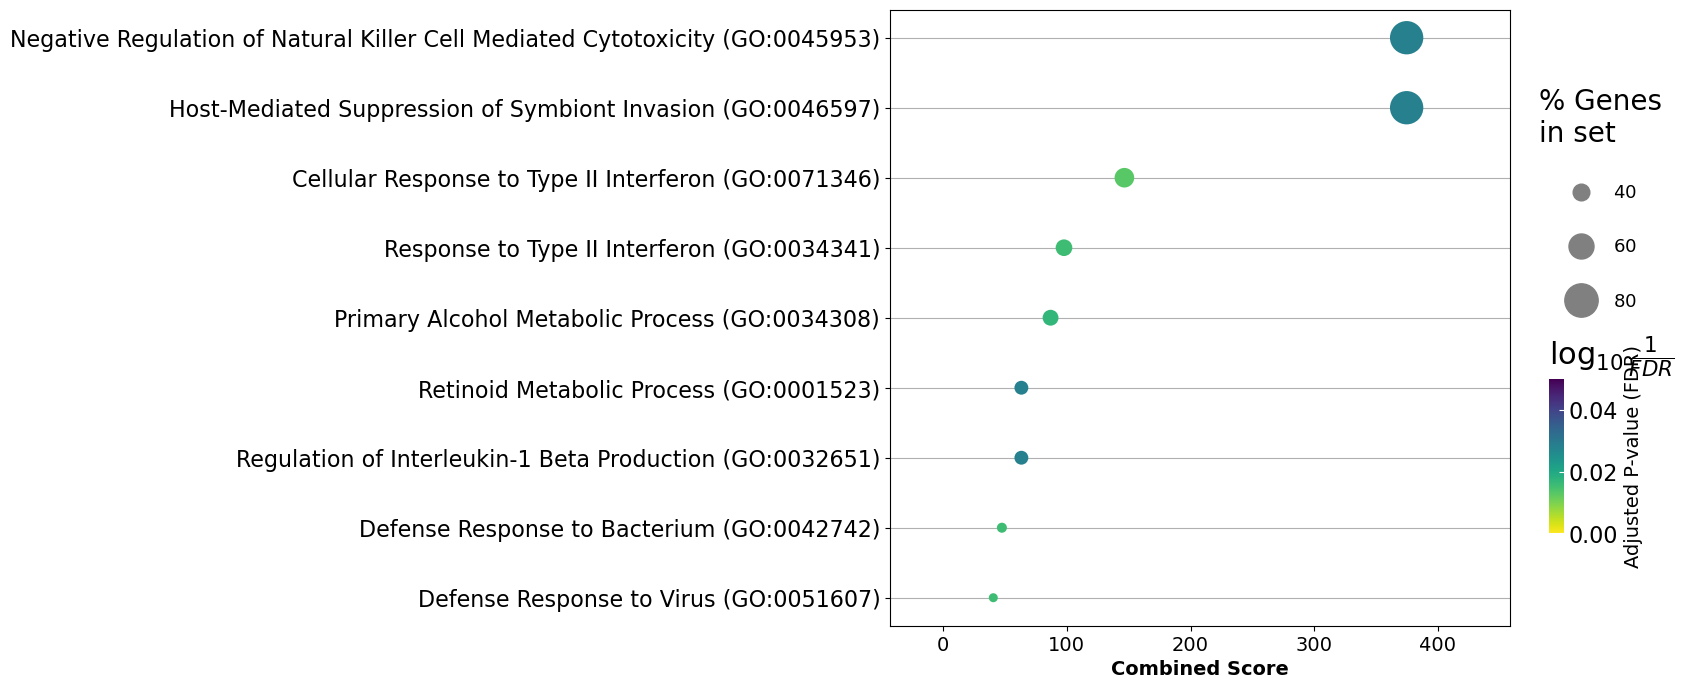

In [169]:
# ============================================================================
# GO dotplot colored by RAW Adjusted P-value (FDR) -- not -log10
# Reuses gseapy's layout (term selection, dot sizes, wrapping) unchanged, then
# re-maps the dot color from -log10(FDR) to raw FDR so the colorbar is readable.
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

try:
    _df = go_df
except NameError:
    _df = pd.read_csv("go_enrichment_results_segdup_hotspot_seqRemoved_80percLength.csv")

# 1. Standard gseapy dotplot (layout unchanged)
ax = gp.dotplot(_df, cutoff=0.05, top_term=10, cmap="viridis_r", figsize=(10, 8), ofname=None)

# 2. Re-color the dots from -log10(FDR) to raw FDR
sc = None
for coll in ax.collections:
    arr = coll.get_array()
    if arr is not None and len(arr) > 1:
        sc = coll
sc.set_array(10.0 ** (-sc.get_array()))   # -log10(FDR) -> FDR
sc.set_clim(0.0, 0.05)                      # 0 = most significant
if getattr(sc, "colorbar", None) is not None:
    sc.colorbar.set_label("Adjusted P-value (FDR)", fontsize=14)
    sc.colorbar.update_normal(sc)

ax.figure.savefig("go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength_FDR.png", dpi=300, bbox_inches="tight")
plt.show()
